In [71]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import scipy
from scipy.signal import find_peaks

plt.style.use('moje.mplstyle')

In [72]:
UR = np.genfromtxt(r'S:\1.FILE\eqn\ur.csv', delimiter=',', skip_header=1)

t = UR[: , 0]/1e6
u = UR[: , 1]/30
r = UR[: , 2]/1e3

In [73]:
ABR = np.genfromtxt(r'S:\1.FILE\eqn\abr.csv', delimiter=',', skip_header=1)

tt = ABR[: , 0]/1e6
a = ABR[: , 1]/1e3
b = ABR[: , 2]/1e3
rr = ABR[: , 3]/1e3

In [112]:
CDR = np.genfromtxt(r'S:\1.FILE\sch_cdr.csv', delimiter=',', skip_header=1)

ttt = CDR[: , 0]/1e6
c = CDR[: , 1]/1e3
d = CDR[: , 2]/1e3
rrr = CDR[: , 3]/1e3

(995.0, 1010.0)

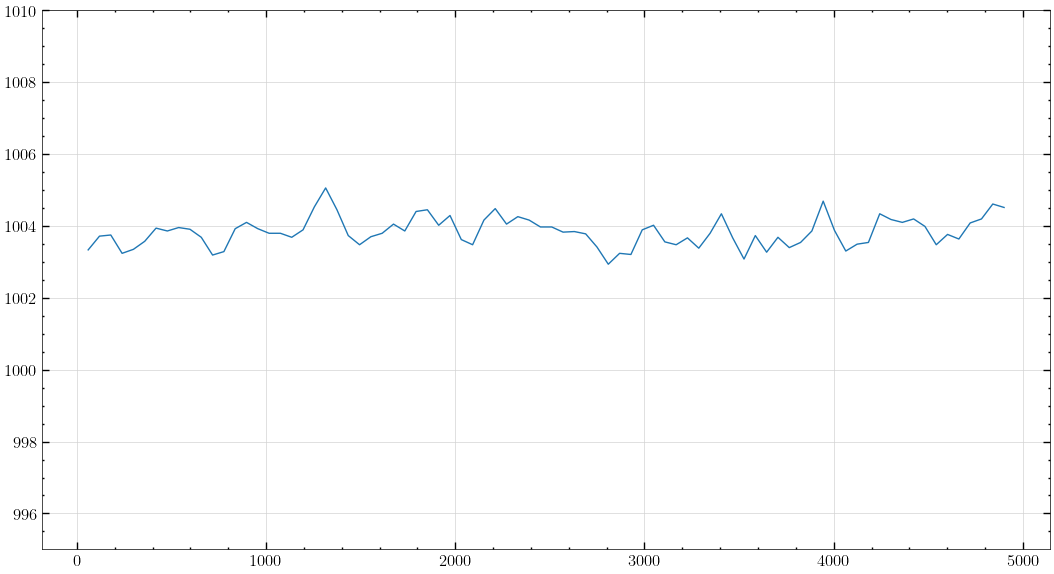

In [113]:
peaks, _ = find_peaks(rrr, height=0.2)
indexy = ttt[peaks[0]]
#print(ttt[peaks])
otacky=[]
ttt_ot=[]
for v in range(len(ttt[peaks])-1):
    #print((1/(ttt[peaks[v+1]] - ttt[peaks[v]]))*6e4)
    if (1/(ttt[peaks[v+1]] - ttt[peaks[v]]))*6e4 < 1200:
        otacky.append((1/(ttt[peaks[v+1]] - ttt[peaks[v]]))*6e4)
        ttt_ot.append(ttt[peaks[v]])

plt.plot(ttt_ot,otacky)
plt.ylim(995,1010)

In [114]:
try:
  def pnej(seznam):
    points = find_peaks(seznam, distance=100000)
    i = 0
    N = []
    for n in points[0]:
        if seznam[n] > 0:
            if i <= 0:
                i += 1
                N.append(n)
    indexy = N[0]
    return indexy                
except IndexError:
  R, RR, RRR = 50,100,100

R = t[pnej(r)]
RR = tt[pnej(rr)]
RRR = ttt[pnej(rrr)]

def timel(leng,okno,jaky):
    if jaky == "R":
        jaky = R
    elif jaky == "RR":
        jaky = RR
    elif jaky == "RRR":
        jaky = RRR

    N1 = np.linspace(jaky-(-1 * ((leng-1) /2)) * okno , jaky-((leng-1) /2)* okno,leng)
    N2 = np.linspace(-1 * ((leng-1) /2) * okno , ((leng-1) /2) * okno,leng)
    N1 = N1.tolist()
    N1.sort()
    N2 = N2.tolist()
    N2 = ["%.2f" % member for member in N2]

    return(N1,N2)

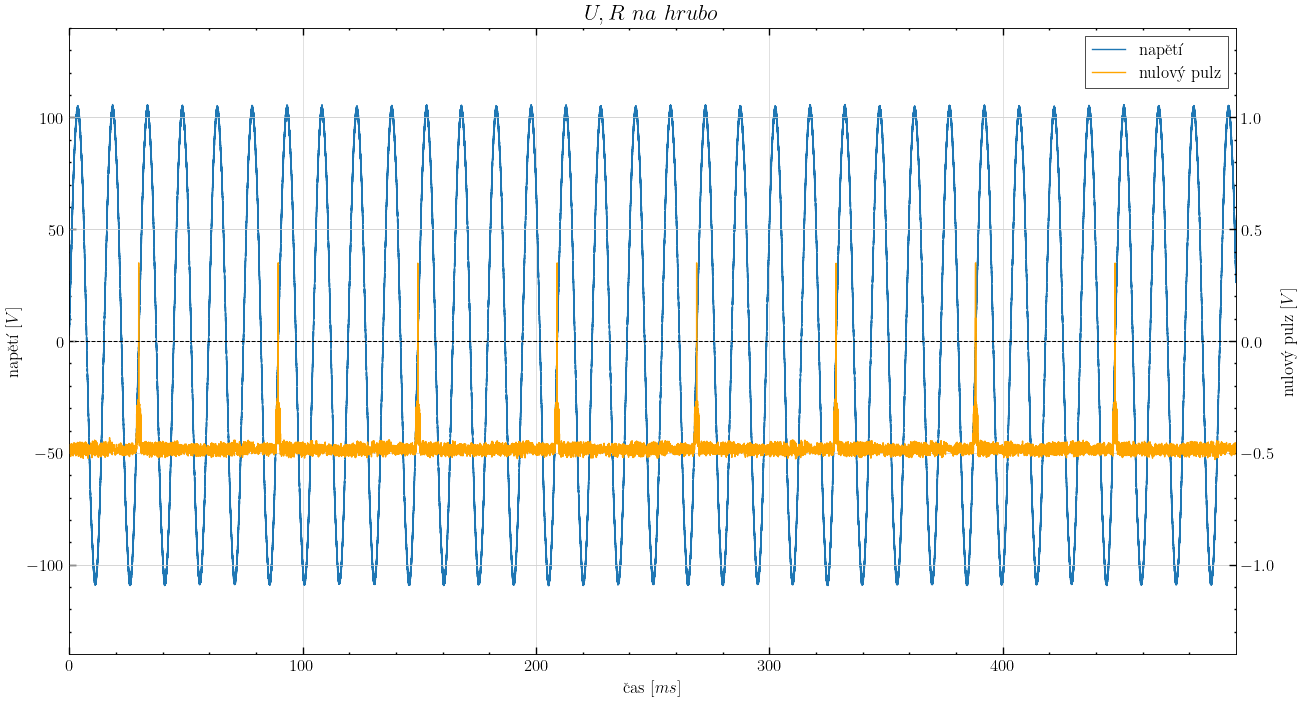

In [77]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax2 = host.twinx()  
host.set_xlim(0, t[-1])
host.set_ylim(-140, 140)
ax2.set_ylim(-1.4, 1.4)

host.set_xlabel("čas $[ms]$", fontsize=12)
host.set_ylabel("napětí $[V]$", fontsize=12)
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12)

p1 = host.plot(t, u, label="napětí")
p2 = ax2.plot(t, r, label="nulový pulz", color='orange')

plt.hlines(0.00075/2,0, t[-1], color = 'k', linestyles='--',lw = 0.75)

# plt.title("U,R na hrubo")
plt.title(r"$U,R$ $na$ $hrubo$", fontsize=16, color='k')
host.legend(handles=p1+p2, loc='upper right')
# host.set_yticks(np.arange(-120, 140, step=40))
host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(p2[0].get_color())
# host.grid(color='lightgrey', linestyle='-', linewidth=0.5)
host.set_xlabel("čas $[ms]$", fontsize=12, color = 'k')
host.set_ylabel("napětí $[V]$", fontsize=12, color = 'k')
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12, color = 'k')
# ax = plt.gca()
# ax.spines['bottom'].set_color('k')
# ax.spines['top'].set_color('k') 
# ax.spines['right'].set_color(p2[0].get_color())
# ax.spines['left'].set_color(p1[0].get_color())

plt.savefig("ur-h.png")

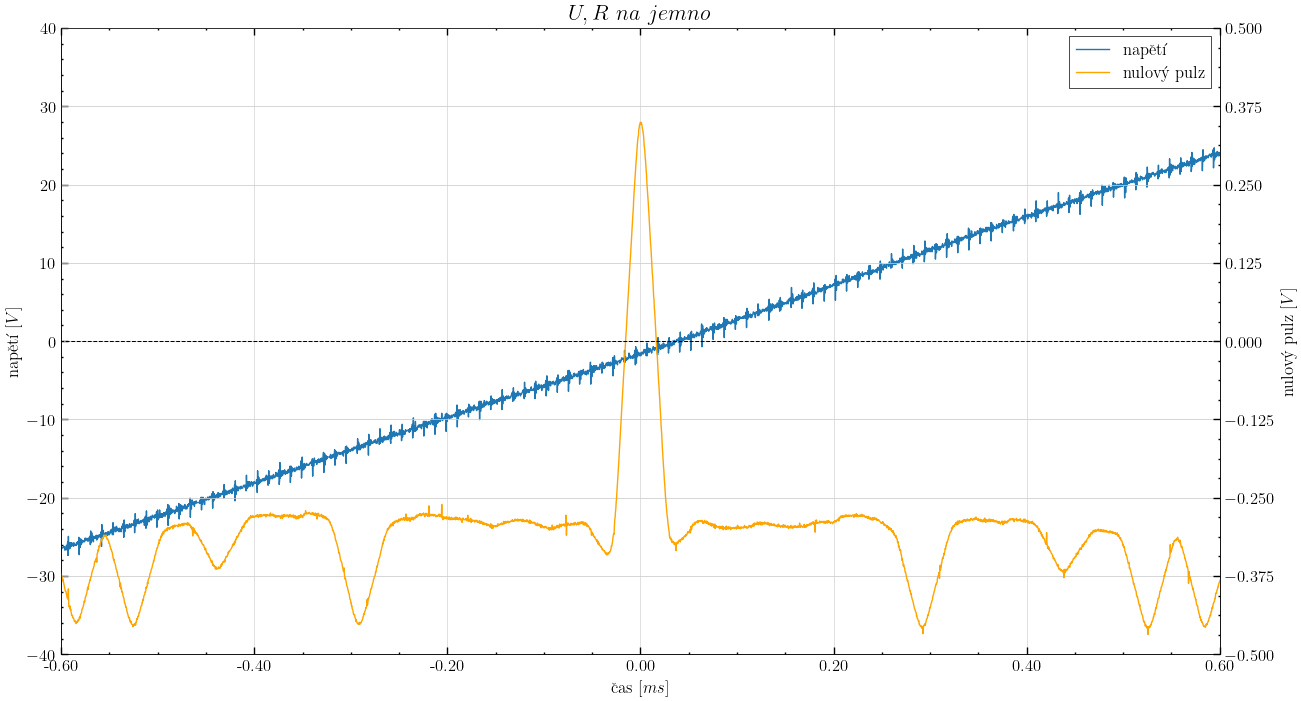

In [78]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax2 = host.twinx()
ax = plt.gca()
    
host.set_xlim(R-0.6, R+0.6)
host.set_ylim(-40, 40)
ax2.set_ylim(-0.5, 0.5)

p1 = host.plot(t, u, label="napětí")
p2 = ax2.plot(t, r, label="nulový pulz", color='orange')
ax2.set_yticks(np.arange(-0.5, 0.5+0.5/4, step=0.5/4))
plt.hlines(0,0,t[-1],color = 'k', linestyles='--',lw = 0.75)
plt.title("$U,R$ $na$ $jemno$", fontsize=16, color='k')
host.legend(handles=p1+p2, loc='upper right')
host.set_yticks(np.arange(-40, 50, step=10))
host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(p2[0].get_color())


# ax.set_xticks([R,R-0.2,R+0.2,R-0.4,R+0.4,R-0.6,R+0.6]) 
# ax.set_xticklabels(['0',"-0.2","0.2","-0.4","0.4","-0.6","0.6"])
N1 , N2 = timel(7,0.2,"R")
ax.set_xticks(N1) 
ax.set_xticklabels(N2)
host.set_xlabel("čas $[ms]$", fontsize=12, color = 'k')
host.set_ylabel("napětí $[V]$", fontsize=12, color = 'k')
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12, color = 'k')

# plt.show()
plt.savefig("ur.png")

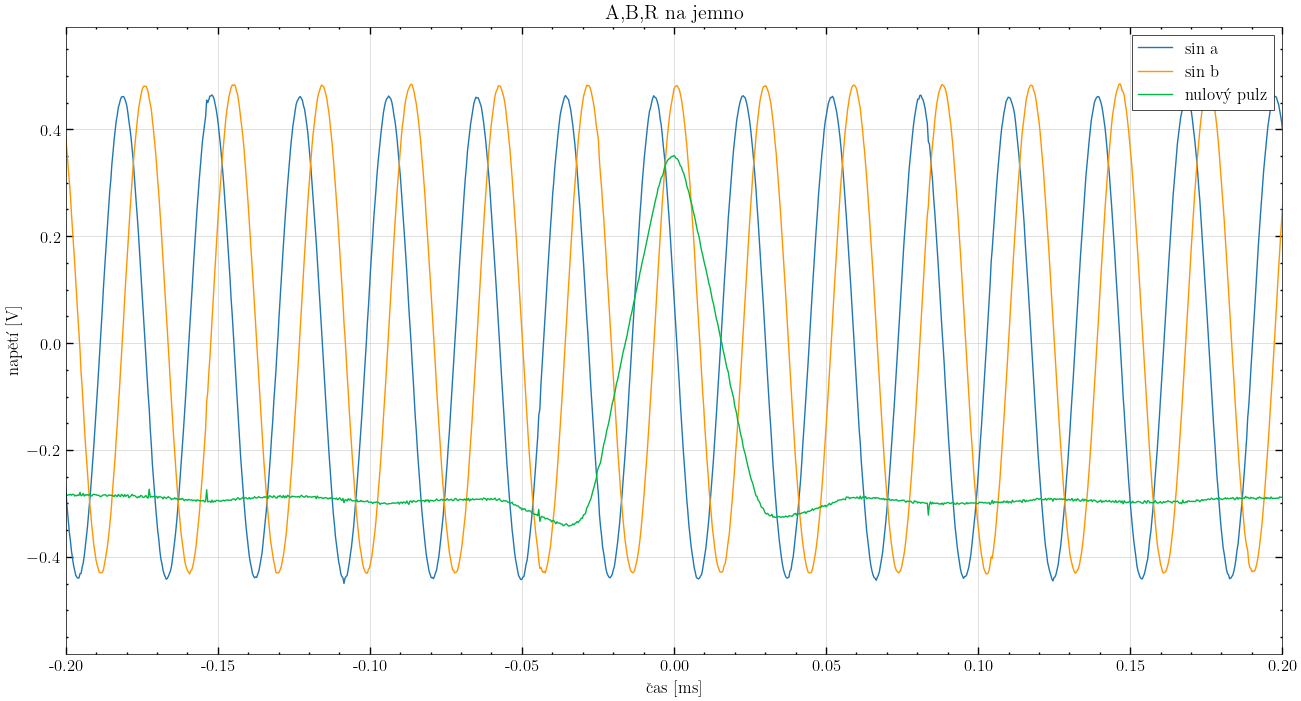

In [79]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax = plt.gca()
plt.title("A,B,R na jemno")
p1 = plt.plot(tt,a, label="sin a")
p2 = plt.plot(tt,b, label="sin b")
p3 = plt.plot(tt,rr, label="nulový pulz")
plt.xlim(RR-0.2,RR+0.2)
host.set_xlabel("čas [ms]")
host.set_ylabel("napětí [V]")
host.legend(handles=p1+p2+p3, loc='upper right')
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5)
# # plt.show()
N1 , N2 = timel(9,0.05,"RR")
# ax.set_xticks([RR,RR-0.2,RR+0.2,RR-0.1,RR+0.1])#,RR-0.4,RR+0.4,RR-0.6,RR+0.6]) 
# ax.set_xticklabels(['0',"-0.2","0.2","-0.1","0.1"])#,"-0.4","+0.4","-0.6","+0.6"])
ax.set_xticks(N1) 
ax.set_xticklabels(N2)

# plt.show()
plt.savefig("abr.png")

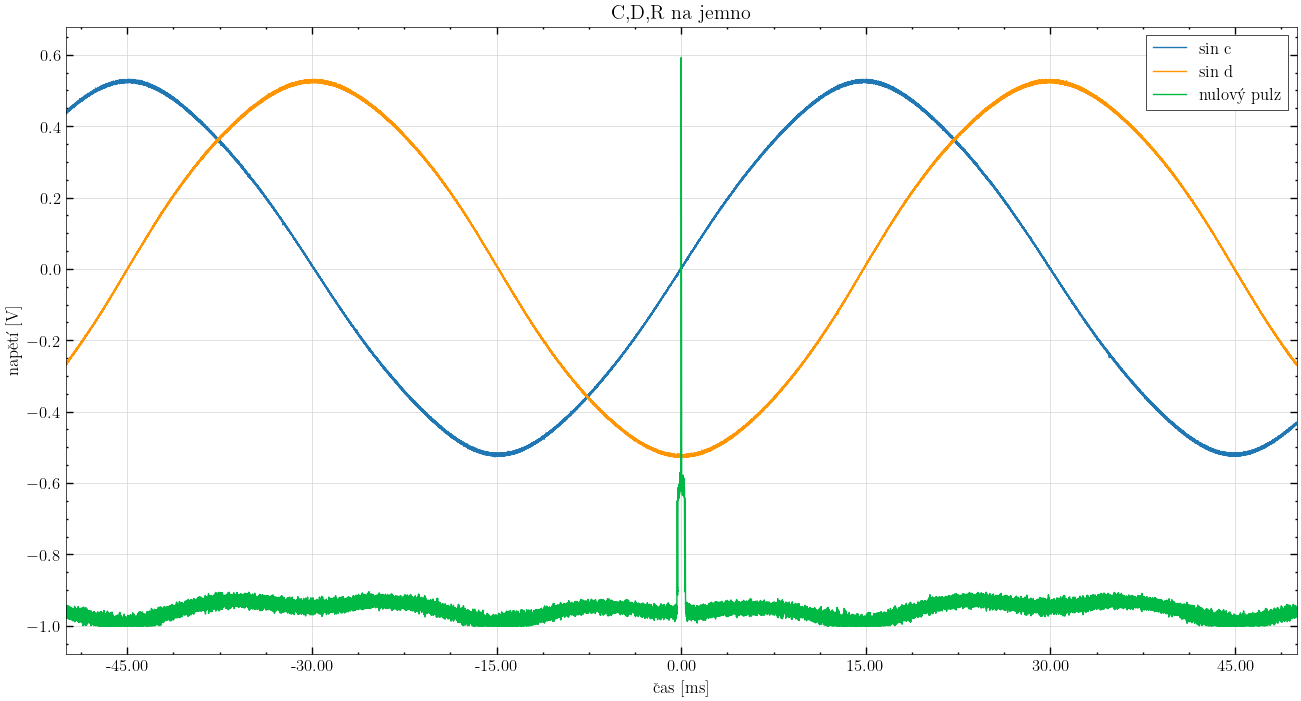

In [115]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax = plt.gca()
plt.title("C,D,R na jemno")
p1 = plt.plot(ttt,c, label="sin c")
p2 = plt.plot(ttt,d, label="sin d")
p3 = plt.plot(ttt,rrr, label="nulový pulz")
host.set_xlabel("čas [ms]")
host.set_ylabel("napětí [V]")
host.legend(handles=p1+p2+p3, loc='upper right')
plt.xlim(RRR-50,RRR+50)

# ax.set_xticks([RRR,RRR-15,RRR+15,RRR-30,RRR+30,RRR-45,RRR+45])
# ax.set_xticklabels(['0',"-15","15","-30","30","-45","45"])
N1 , N2 = timel(7,15,"RRR")
ax.set_xticks(N1) 
ax.set_xticklabels(N2)

plt.grid(color='lightgrey', linestyle='-', linewidth=0.5)
# plt.show()
plt.savefig("cdr.png")

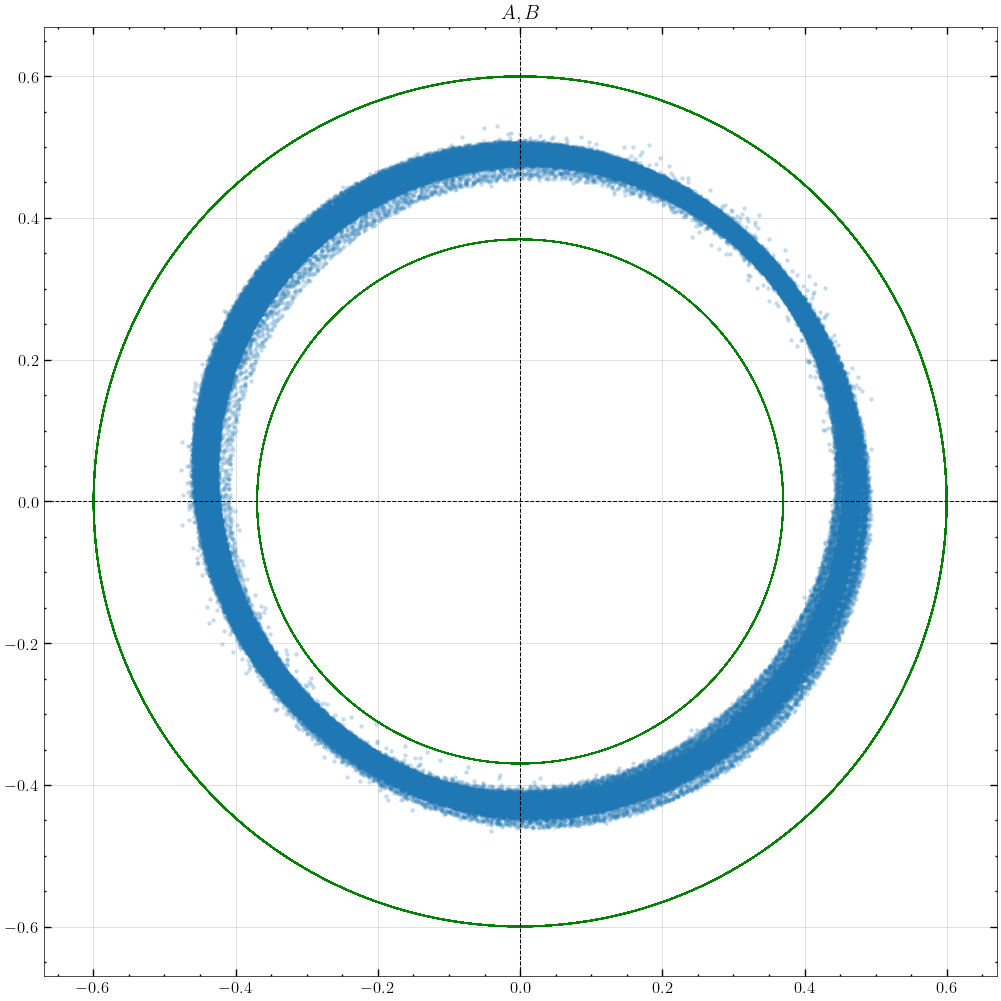

In [81]:
x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0
fig = plt.subplots(figsize=(10,10), layout='constrained')
plt.title("$A,B$")
plt.plot(y,yy, lw = 0.75,color = 'g')
plt.plot(w,ww, lw = 0.75,color = 'g')
# plt.scatter(a,b, linewidths= 0.1, marker=".", alpha=0.005)
plt.scatter(a[0:len(a)//6],b[0:len(b)//6], linewidths= 0.1, marker=".", alpha=0.25)
plt.xlim(-0.67,0.67)
plt.ylim(-0.67,0.67)
plt.vlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
plt.hlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
# plt.savefig("kola.png")
plt.show()

Změřená frekvence signálu: 34294.03 Hz


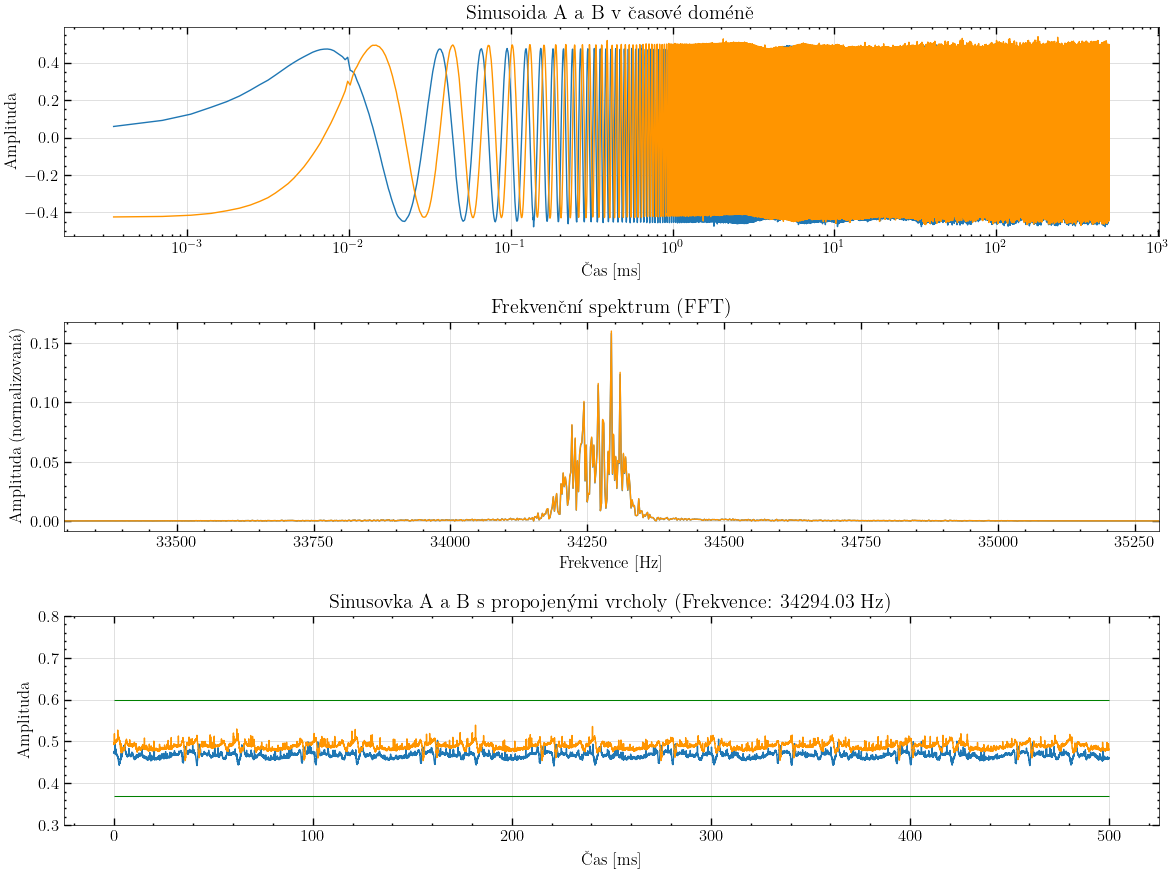

In [82]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt


def propoj_vrcholy_sinusovky(frekvence, vzorkovaci_frekvence, sinusoida, casova_osa):
    min_vzdalenost_mezi_vrcholy = int(vzorkovaci_frekvence / frekvence * 0.8) # 0.8 pro jistotu
    vrcholy_indexy, _ = find_peaks(sinusoida, distance=min_vzdalenost_mezi_vrcholy)
    # Získání hodnot časové osy a amplitudy pro nalezené vrcholy
    cas_vrcholu = casova_osa[vrcholy_indexy]
    amplituda_vrcholu = sinusoida[vrcholy_indexy]
    return cas_vrcholu, amplituda_vrcholu

def measure_frequency_of_sine_wave(signal_data, sample_rate):

    N = len(signal_data)  # Počet vzorků
    yf = fft(signal_data) # Provede rychlou Fourierovu transformaci
    xf = fftfreq(N, 1 / sample_rate) # Vypočítá frekvenční osy

    # Vezmeme pouze kladné frekvence (spektrum je symetrické)
    # Ignorujeme frekvenci 0 Hz (stejnosměrnou složku)
    positive_freq_indices = np.where(xf > 0)
    xf_positive = xf[positive_freq_indices]
    yf_positive = np.abs(yf[positive_freq_indices])

    # Najdeme index frekvence s největší amplitudou
    dominant_frequency_index = np.argmax(yf_positive)
    dominant_frequency = xf_positive[dominant_frequency_index]

    return dominant_frequency

# Výpočet frekvence

sample_rate = 1/350e-9  # Vzorkovací frekvence v Hz (např. 1000 vzorků za sekundu)
duration = tt[-1]      # Doba trvání signálu v sekundách

# --- Měření frekvence ---
measured_freq = measure_frequency_of_sine_wave(a, sample_rate)
print(f"Změřená frekvence signálu: {measured_freq:.2f} Hz")
cas_vrcholu, amplituda_vrcholu = propoj_vrcholy_sinusovky(measured_freq, sample_rate, a, tt)
cas_vrcholu_b, amplituda_vrcholu_b = propoj_vrcholy_sinusovky(measured_freq, sample_rate, b, tt)


# --- Volitelná vizualizace ---

plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.plot(tt,a, label="sin A")
plt.plot(tt, b, label="sin B")
plt.title('Sinusoida A a B v časové doméně')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.xscale("log")
#plt.legend(bbox_to_anchor=(0,1,1,.1), ncol=2, mode = "expand", loc = "lower left")

# Zobrazení frekvenčního spektra

Na = len(a)
Ta = 1/sample_rate
yfa = fft(a)
xfa = fftfreq(Na, Ta)[:Na//2]

Nb = len(b)
Tb = 1/sample_rate
yfb = fft(b)
xfb = fftfreq(Nb, Tb)[:Nb//2]

plt.subplot(3, 1, 2)
plt.plot(xfa, 2.0/Na * np.abs(yfa[0:Na//2]))
plt.plot(xfb, 2.0/Nb * np.abs(yfb[0:Nb//2]))
plt.title('Frekvenční spektrum (FFT)')
plt.xlabel('Frekvence [Hz]')
plt.ylabel('Amplituda (normalizovaná)')
plt.grid(True)
# plt.xlim(0, measured_freq * 2) # Omezíme zobrazení na zajímavou část spektra
plt.xlim(measured_freq - 1000, measured_freq + 1000) # Omezíme zobrazení na zajímavou část spektra

plt.subplot(3, 1, 3)
#plt.plot(tt, a, label='Původní sinusovka')
# Spojení vrcholů čarami
plt.plot(cas_vrcholu, amplituda_vrcholu, label='Spojené vrcholy')
plt.plot(cas_vrcholu_b, amplituda_vrcholu_b, label='Spojené vrcholy')
plt.hlines(0.37,0,cas_vrcholu[-1],color = 'g',lw = 0.75)
plt.hlines(0.6,0,cas_vrcholu[-1],color = 'g',lw = 0.75)
plt.title(f'Sinusovka A a B s propojenými vrcholy (Frekvence: {measured_freq:.2f} Hz)')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
#plt.legend()
plt.ylim(0.3,0.8)
plt.tight_layout()
plt.show()

17137 17137


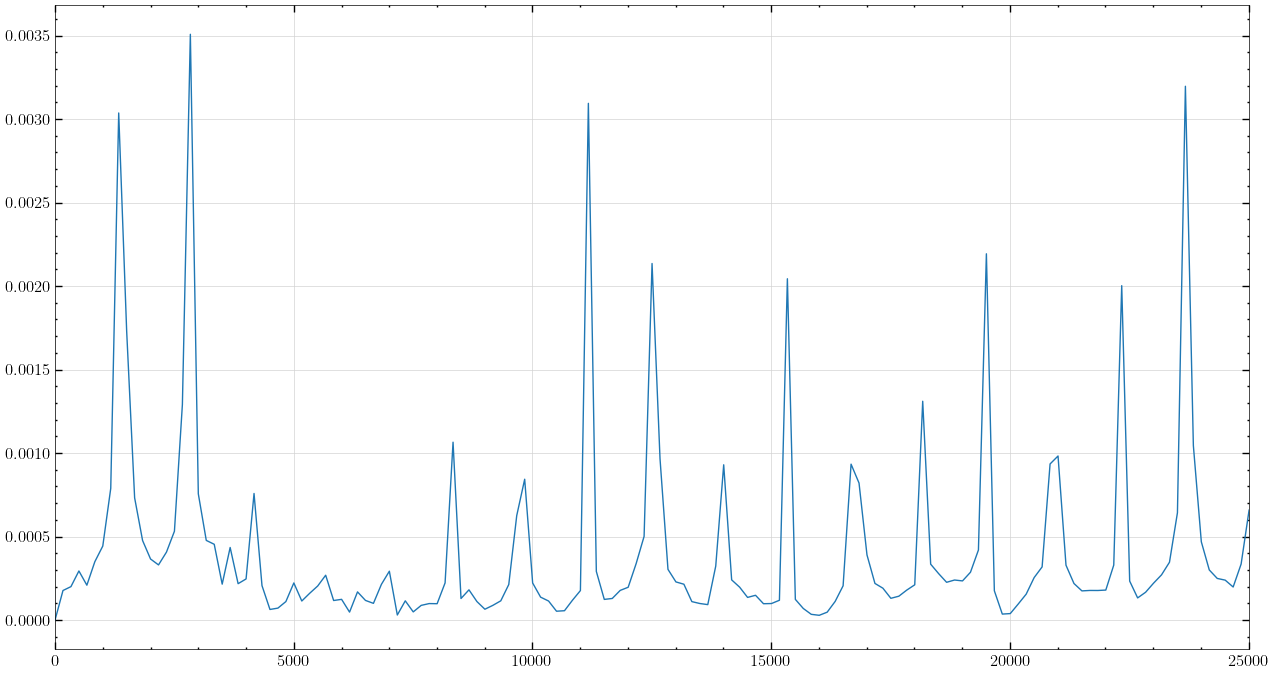

In [83]:
print(len(cas_vrcholu), len(amplituda_vrcholu))
e = (amplituda_vrcholu-np.mean(amplituda_vrcholu))
Ne = len(e)
Te = 1/sample_rate
yfe = fft(e)
xfe = fftfreq(Ne, Te)[:Ne//2]
#plt.plot(cas_vrcholu, (amplituda_vrcholu-np.mean(amplituda_vrcholu))*1000)
plt.plot(xfe, 2.0/Ne * np.abs(yfe[0:Ne//2]))

#plt.title(f'Sinusovka A a B s propojenými vrcholy (Frekvence: {measured_freq:.2f} Hz)')
#plt.xlabel('Čas [ms]')
#plt.ylabel('Amplituda')
#plt.legend()
plt.xlim(0,25000)
plt.tight_layout()
plt.show()

Změřená frekvence signálu: 16.80 Hz


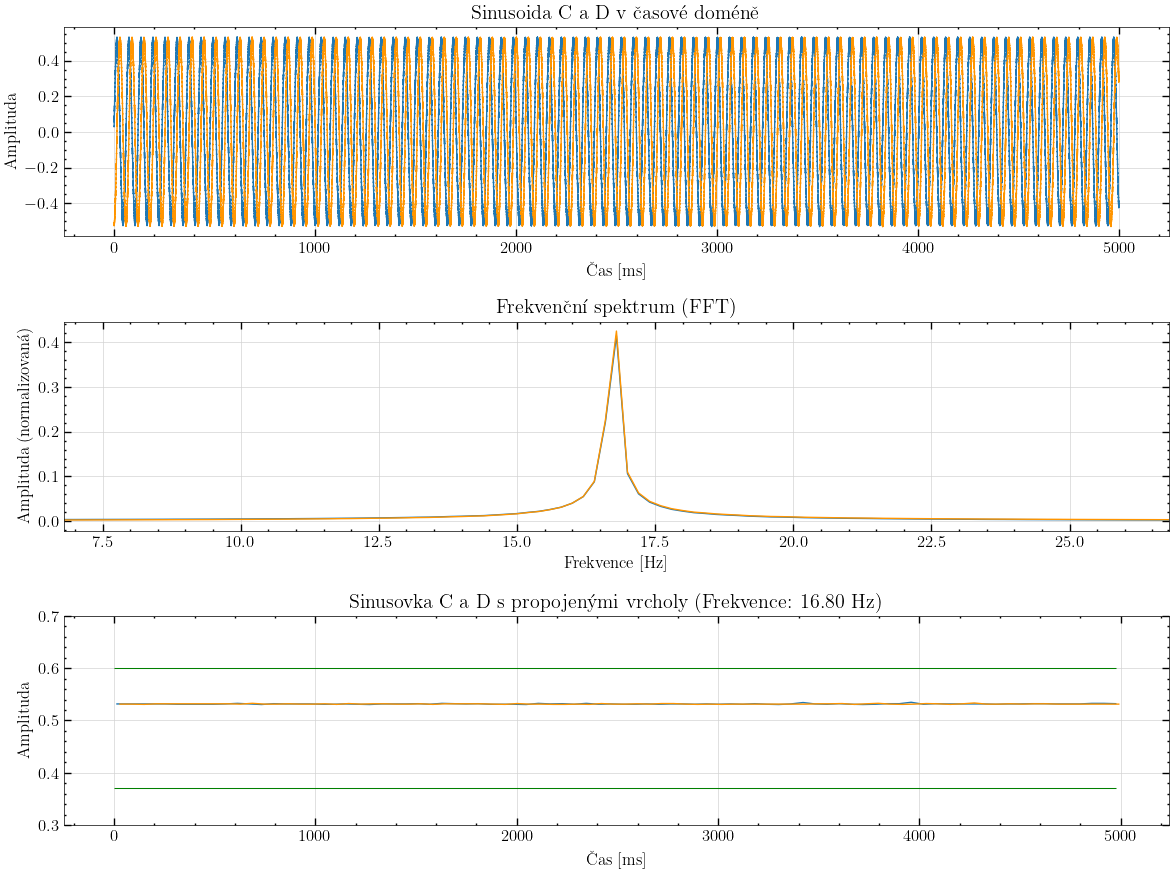

In [116]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt


def propoj_vrcholy_sinusovky(frekvence, vzorkovaci_frekvence, sinusoida, casova_osa):
    min_vzdalenost_mezi_vrcholy = int(vzorkovaci_frekvence / frekvence * 0.8) # 0.8 pro jistotu
    vrcholy_indexy, _ = find_peaks(sinusoida, distance=min_vzdalenost_mezi_vrcholy)
    # Získání hodnot časové osy a amplitudy pro nalezené vrcholy
    cas_vrcholu = casova_osa[vrcholy_indexy]
    amplituda_vrcholu = sinusoida[vrcholy_indexy]
    return cas_vrcholu, amplituda_vrcholu

def measure_frequency_of_sine_wave(signal_data, sample_rate):

    N = len(signal_data)  # Počet vzorků
    yf = fft(signal_data) # Provede rychlou Fourierovu transformaci
    xf = fftfreq(N, 1 / sample_rate) # Vypočítá frekvenční osy

    # Vezmeme pouze kladné frekvence (spektrum je symetrické)
    # Ignorujeme frekvenci 0 Hz (stejnosměrnou složku)
    positive_freq_indices = np.where(xf > 0)
    xf_positive = xf[positive_freq_indices]
    yf_positive = np.abs(yf[positive_freq_indices])

    # Najdeme index frekvence s největší amplitudou
    dominant_frequency_index = np.argmax(yf_positive)
    dominant_frequency = xf_positive[dominant_frequency_index]

    return dominant_frequency

# Výpočet frekvence

sample_rate = 1/950e-9  # Vzorkovací frekvence v Hz (např. 1000 vzorků za sekundu)
duration = ttt[-1]      # Doba trvání signálu v sekundách

# --- Měření frekvence ---
measured_freq_c = measure_frequency_of_sine_wave(c, sample_rate)
print(f"Změřená frekvence signálu: {measured_freq_c:.2f} Hz")
cas_vrcholu_c, amplituda_vrcholu_c = propoj_vrcholy_sinusovky(measured_freq_c, sample_rate, c, ttt)
cas_vrcholu_d, amplituda_vrcholu_d = propoj_vrcholy_sinusovky(measured_freq_c, sample_rate, d, ttt)


# --- Volitelná vizualizace ---

plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.plot(ttt,c)
plt.plot(ttt, d)
plt.title('Sinusoida C a D v časové doméně')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
plt.grid(True)
#plt.legend(bbox_to_anchor=(0,1,1,.1), ncol=2, mode = "expand", loc = "lower left")

# Zobrazení frekvenčního spektra
Nc = len(c)
Tc = 1/sample_rate
yfc = fft(c)
xfc = fftfreq(Nc, Tc)[:Nc//2]

# Zobrazení frekvenčního spektra
Nd = len(d)
Td = 1/sample_rate
yfd = fft(d)
xfd = fftfreq(Nd, Td)[:Nd//2]

plt.subplot(3, 1, 2)
plt.plot(xfc, 2.0/Nc * np.abs(yfc[0:Nc//2]))
plt.plot(xfd, 2.0/Nd * np.abs(yfd[0:Nd//2]))
plt.title('Frekvenční spektrum (FFT)')
plt.xlabel('Frekvence [Hz]')
plt.ylabel('Amplituda (normalizovaná)')
plt.grid(True)
# plt.xlim(0, measured_freq * 2) # Omezíme zobrazení na zajímavou část spektra
plt.xlim(measured_freq_c - 10, measured_freq_c + 10) # Omezíme zobrazení na zajímavou část spektra

plt.subplot(3, 1, 3)
#plt.plot(tt, a, label='Původní sinusovka')
# Spojení vrcholů čarami
p1 = host.plot(ttt[peaks[:len(otacky)]],otacky)
p2 = ax2.plot(cas_vrcholu_d, amplituda_vrcholu_d, label='Spojené vrcholy', color='orange')
plt.plot(cas_vrcholu_c, amplituda_vrcholu_c, label='Spojené vrcholy')
plt.plot(cas_vrcholu_d, amplituda_vrcholu_d, label='Spojené vrcholy')
plt.plot(ttt[peaks[:len(otacky)]],otacky)
plt.hlines(0.37,0,cas_vrcholu_c[-1],color = 'g',lw = 0.75)
plt.hlines(0.6,0,cas_vrcholu_c[-1],color = 'g',lw = 0.75)
plt.title(f'Sinusovka C a D s propojenými vrcholy (Frekvence: {measured_freq_c:.2f} Hz)')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
#plt.legend()
plt.ylim(0.3,0.7)
plt.tight_layout()
plt.show()

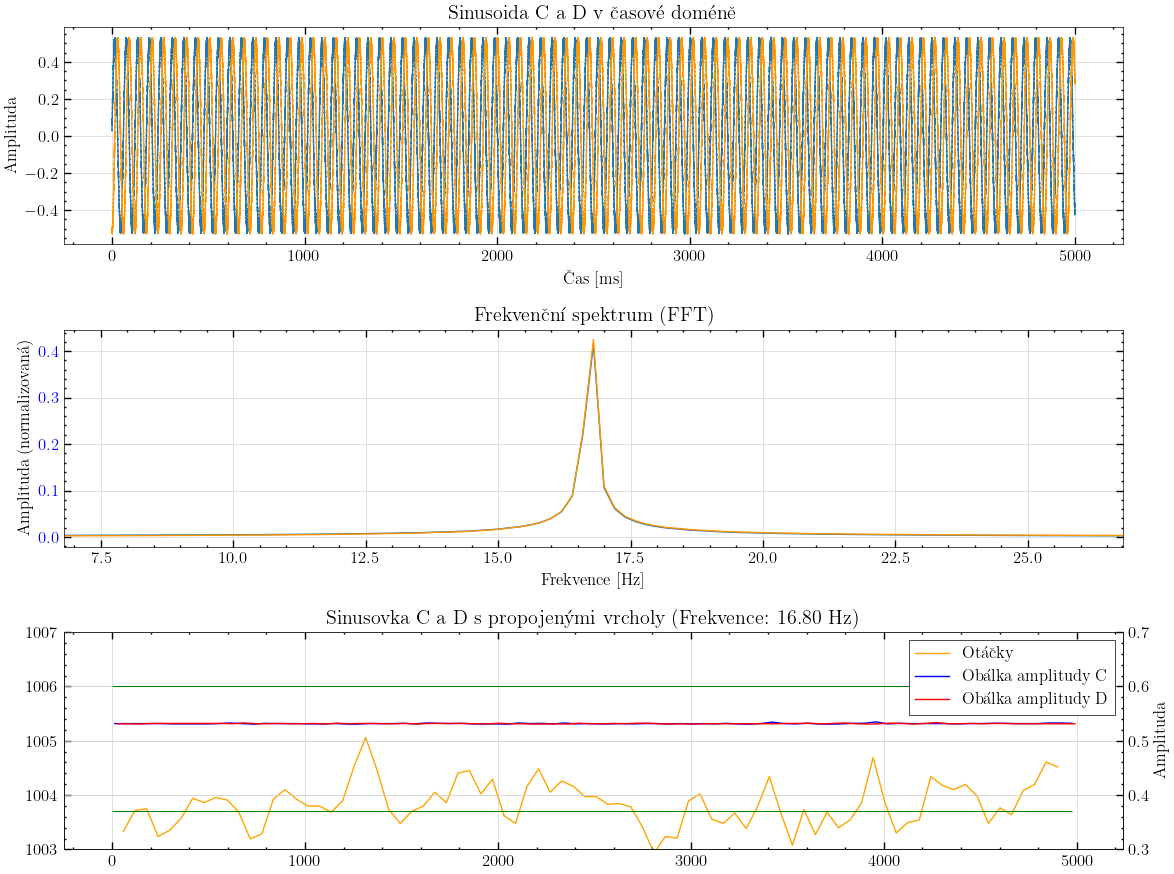

In [117]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(12, 9)) 


# --- První subplot (axes[0]) ---
ax1_subplot1 = axes[0] # Získáme první osu (subplot)
ax1_subplot1.plot(ttt,c)
ax1_subplot1.plot(ttt, d)
ax1_subplot1.set_title('Sinusoida C a D v časové doméně')
ax1_subplot1.set_xlabel('Čas [ms]')
ax1_subplot1.set_ylabel('Amplituda')
ax1_subplot1.grid(True)

# --- Druhý subplot (axes[1]) s pomocnou osou ---
ax1_subplot11 = axes[1] # Získáme druhou osu (subplot), která bude mít primární Y osu

# # Vykreslení primární datové sady na ax1_subplot2
ax1_subplot11.plot(xfc, 2.0/Nc * np.abs(yfc[0:Nc//2]))
ax1_subplot11.plot(xfd, 2.0/Nd * np.abs(yfd[0:Nd//2]))
ax1_subplot11.set_title('Frekvenční spektrum (FFT)')
ax1_subplot11.set_xlabel('Frekvence [Hz]')
ax1_subplot11.set_ylabel('Amplituda (normalizovaná)')
ax1_subplot11.tick_params(axis='y', labelcolor='blue')
ax1_subplot11.set_xlim(measured_freq_c - 10, measured_freq_c + 10) # Omezíme zobrazení na zajímavou část spektra

ax1_subplot2 = axes[2]
# Vykreslení primární datové sady na ax1_subplot2
ax1_subplot2.plot(ttt_ot,otacky, label='Otáčky', color='orange')
ax1_subplot2.set_ylim(1003,1007)

# Vytvoření pomocné osy pro druhý subplot
ax2_subplot2 = ax1_subplot2.twinx() # Pomocná osa sdílí X osu s ax1_subplot2

# Vykreslení sekundární datové sady na ax2_subplot2
ax2_subplot2.plot(cas_vrcholu_c, amplituda_vrcholu_c, label='Obálka amplitudy C ', color='blue')
ax2_subplot2.plot(cas_vrcholu_d, amplituda_vrcholu_d, label='Obálka amplitudy D ', color='red')
# ax2_subplot2.set_ylabel('Osa Y2', color='red')
# ax2_subplot2.tick_params(axis='y', labelcolor='red')
ax2_subplot2.hlines(0.37,0,cas_vrcholu_c[-1],color = 'g',lw = 0.75)
ax2_subplot2.hlines(0.6,0,cas_vrcholu_c[-1],color = 'g',lw = 0.75)
ax2_subplot2.set_title(f'Sinusovka C a D s propojenými vrcholy (Frekvence: {measured_freq_c:.2f} Hz)')
ax2_subplot2.set_xlabel('Čas [ms]')
ax2_subplot2.set_ylabel('Amplituda')
ax2_subplot2.set_ylim(0.3,0.7)
ax1_subplot2.grid(True)

# Společná legenda pro druhý subplot
lines, labels = ax1_subplot2.get_legend_handles_labels()
lines2, labels2 = ax2_subplot2.get_legend_handles_labels()
ax2_subplot2.legend(lines + lines2, labels + labels2, loc='upper right')

# 3. Zobrazení grafu
fig.tight_layout()
plt.show()

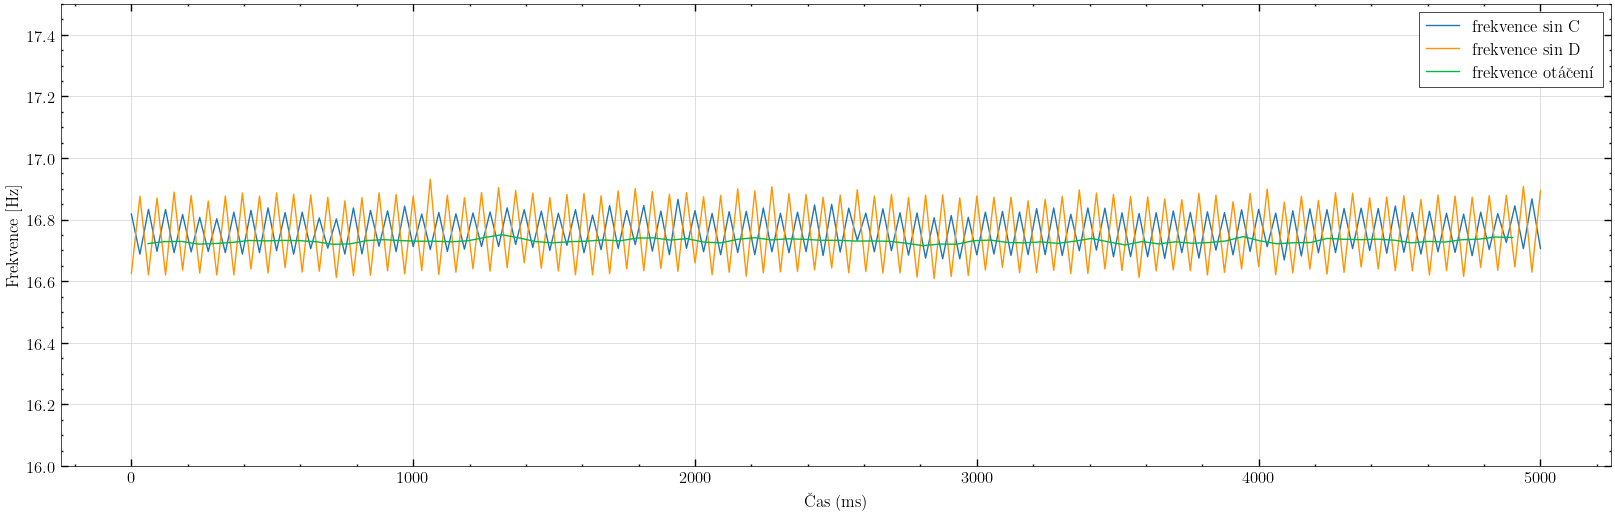

In [119]:
import numpy as np
import matplotlib.pyplot as plt


def zero(sine_wave):
    zero_crossings = []
    for i in range(1, len(sine_wave)):
        # Kontrola, zda došlo k průchodu nulou (změna znaménka)
        if (sine_wave[i-1] < 0 and sine_wave[i] >= 0) or \
            (sine_wave[i-1] > 0 and sine_wave[i] <= 0) :
            zero_crossings.append(ttt[i])

    # Měření času mezi průchody nulou
    time_diffs = []
    for i in range(1, len(zero_crossings)-1):
        cas = zero_crossings[i+1] - zero_crossings[i]
        if cas > 20.0:
            time_diffs.append(cas)
    return time_diffs
tc = zero(c)
td = zero(d)
# Vizualizace sinusovky a průchodů nulou
plt.figure(figsize=(20, 6))
plt.plot(np.linspace(0,ttt[-1],len((1/np.array(tc)/2))),(1/np.array(tc)/2e-3), label="frekvence sin C")
plt.plot(np.linspace(0,ttt[-1],len((1/np.array(td)/2))),(1/np.array(td)/2e-3), label="frekvence sin D")
plt.plot(ttt_ot,np.array(otacky)/60, label="frekvence otáčení")
#plt.plot(ttt, sine_wave, label='Sinusová vlna')
#plt.scatter(zero_crossings, np.zeros_like(zero_crossings), color='red', zorder=5, label='Průchody nulou')
plt.ylim(16,17.5)
plt.xlabel('Čas (ms)')
plt.ylabel('Frekvence [Hz]')
plt.grid(True)
#plt.axhline(1004/60, color='gray', linestyle='--', linewidth=0.8) # Osy pro nulu
plt.legend()
plt.show()

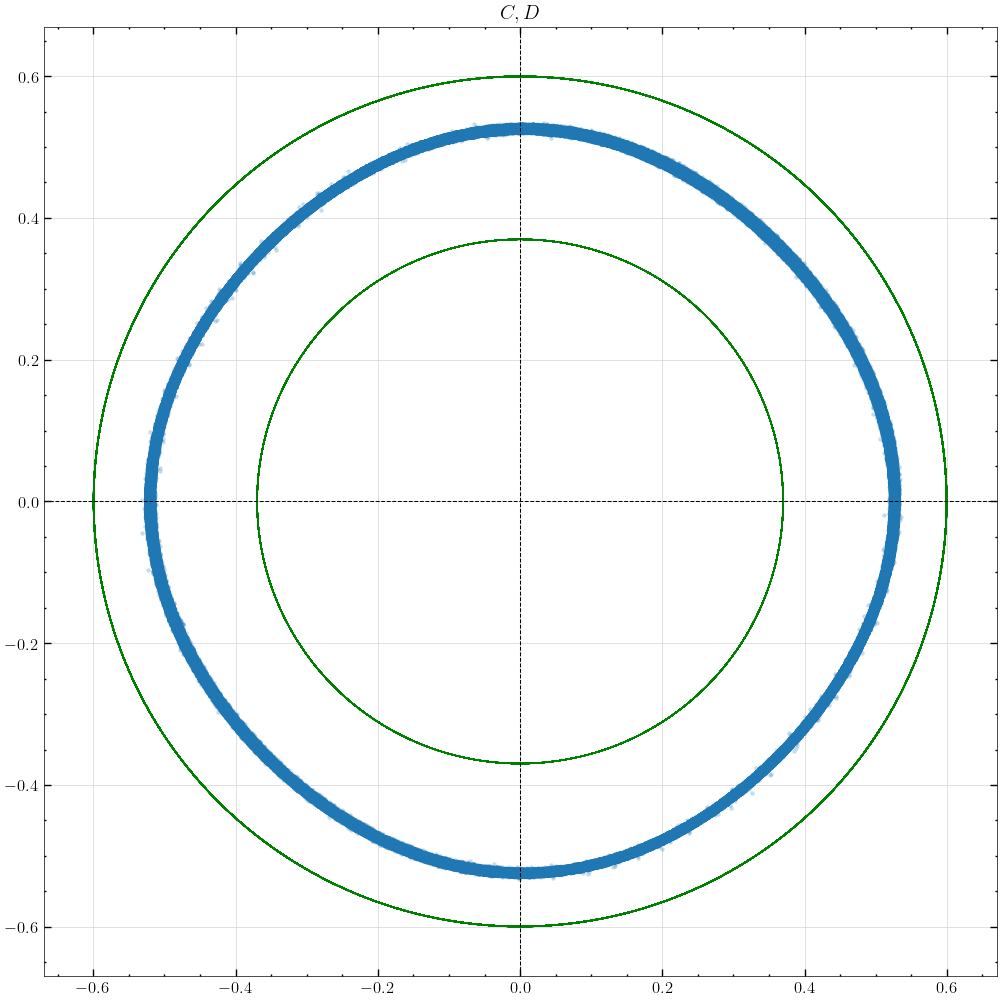

In [120]:
x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0
fig = plt.subplots(figsize=(10,10), layout='constrained')
plt.title("$C,D$")
plt.plot(y,yy, lw = 0.75,color = 'g')
plt.plot(w,ww, lw = 0.75,color = 'g')
plt.scatter(c,d, linewidths= 0.1, marker=".", alpha=0.25)
plt.xlim(-0.67,0.67)
plt.ylim(-0.67,0.67)
plt.vlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
plt.hlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)

# plt.savefig("kolc.png")
plt.show()